In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
atto_raw_file = '/Net/Groups/BSI/people/sbotia/data_input/ATTOdata_4LSM/ATTO_data_30min_model_input_evaluation_v1_2014-2023.csv'

In [3]:
df_atto_raw = pd.read_csv(atto_raw_file)
df_atto_raw['datetime'] = pd.to_datetime(df_atto_raw['datetime'])
df_atto_raw.set_index('datetime', inplace=True)
df_atto_raw['Year'] = df_atto_raw.index.year
df_atto_raw['Month'] = df_atto_raw.index.month
df_atto_raw['Day_of_year'] = df_atto_raw.index.dayofyear

In [5]:
df_atto_raw.columns

Index(['Year', 'Month', 'Day', 'Hour', 'Min', 'SW_in_GF (W/m2)', 'SW_in_ID',
       'SW_out', 'LW_atm_calc', 'LW_terr_calc', 'Flux_Tsonic', 'Flux_Op-H2O',
       'NEE_U50_orig', 'NEE_U50_f', 'Tair_55m', 'Tair_55m_ID', 'Tair_36m',
       'Tair_36m_ID', 'RH_55m', 'RH_55m_ID', 'RH_36m', 'RH_36m_ID',
       'AP_55m_kPa', 'AP_55m_kPa_ID', 'AP_36m_kPa', 'AP_36m_kPa_ID',
       'CO2_dry_x_Picarro_55m', 'CO2_dry_x_Picarro_55m_ID',
       'CO2_dry_x_Picarro_36m', 'CO2_dry_x_Picarro_36m_ID', 'Rainfall'],
      dtype='object')

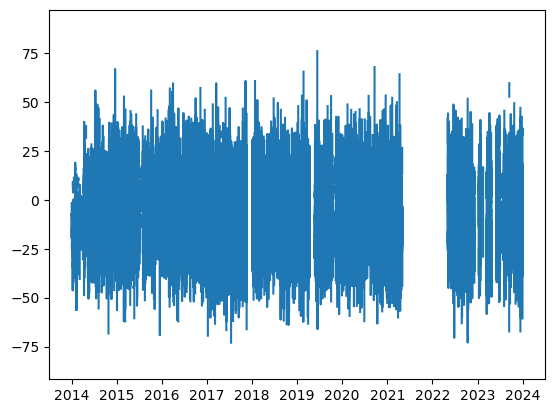

In [4]:
plt.plot(df_atto_raw['NEE_U50_orig'])

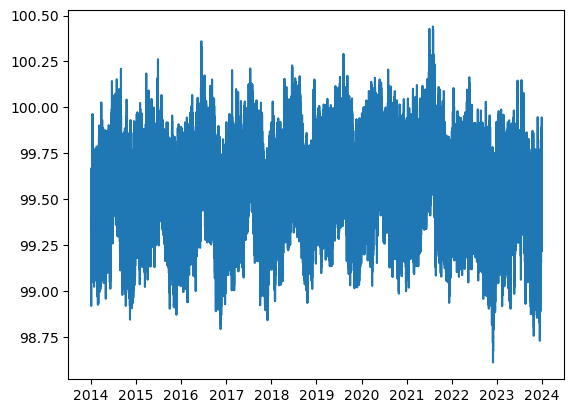

In [33]:
plt.plot(df_atto_raw['AP_36m_kPa'])

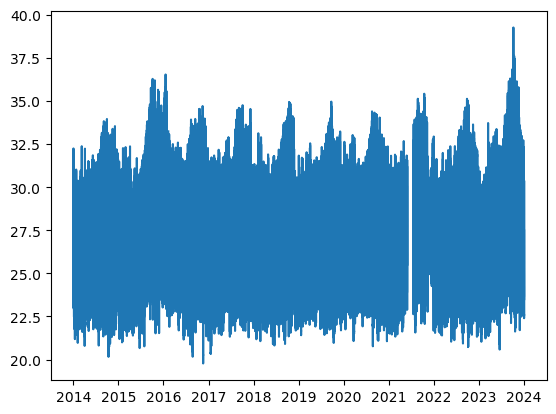

In [30]:
plt.plot(df_atto_raw['Tair_36m'])

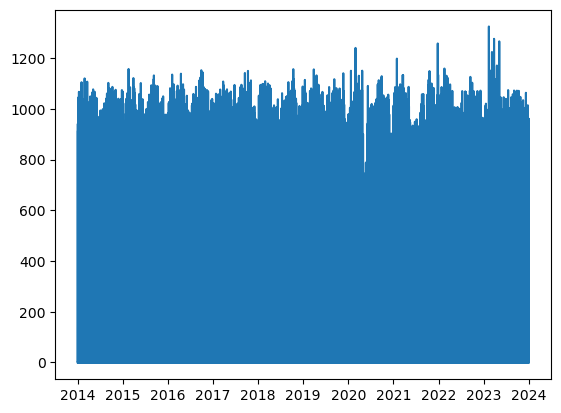

In [20]:
plt.plot(df_atto_raw['SW_in_GF (W/m2)'])

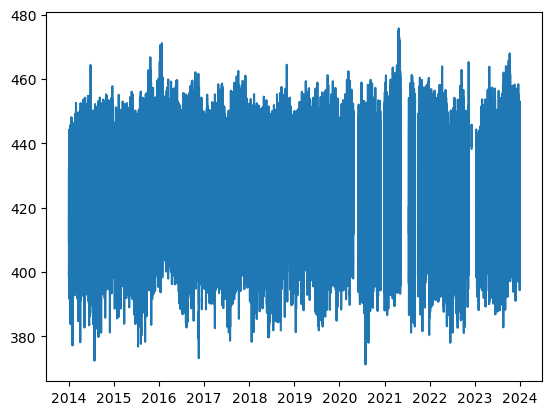

In [23]:
plt.plot(df_atto_raw['LW_atm_calc'])

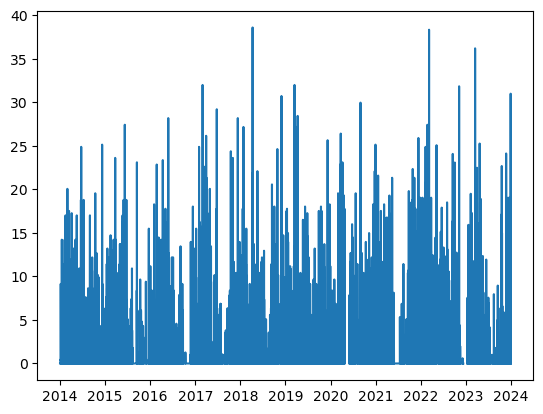

In [ ]:
plt.plot(df_atto_raw['RH_36m'])

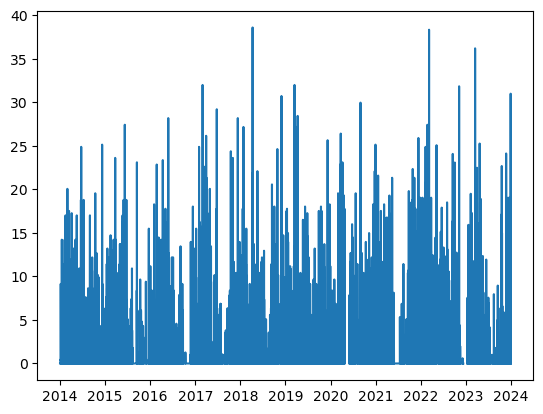

In [28]:
plt.plot(df_atto_raw['Rainfall'])

In [82]:
def calculate_specific_humidity(temperature_celsius, relative_humidity_percent, atmospheric_pressure_hpa):
    """
    Calculates specific humidity from temperature, relative humidity, and atmospheric pressure.

    Args:
        temperature_celsius (float): Temperature in degrees Celsius.
        relative_humidity_percent (float): Relative humidity as a percentage (e.g., 75 for 75%).
        atmospheric_pressure_hpa (float): Atmospheric pressure in hectopascals (hPa).

    Returns:
        float: Specific humidity in kg/kg.
    """

    # 1. Calculate the Saturation Vapor Pressure (Ps) using the Magnus-Tetens formula.
    ps = 6.112 * np.exp((17.62 * temperature_celsius) / (243.12 + temperature_celsius))

    # 2. Calculate the Actual Vapor Pressure (Pv) from relative humidity.
    pv = ps * (relative_humidity_percent / 100)

    # 3. Calculate the Specific Humidity (q) using the atmospheric pressure and actual vapor pressure.
    # The constant 0.622 is the ratio of the molecular weight of water vapor to dry air.
    q = (0.622 * pv) / (atmospheric_pressure_hpa - pv)

    return q


In [37]:
# Example Usage:
# Assume:
# Temperature = 25°C
# Relative Humidity = 60%
# Atmospheric Pressure = 1013.25 hPa

temp = 25.0
rh = 60.0
pressure = 1013.25

specific_humidity = calculate_specific_humidity(temp, rh, pressure)

print(f"The specific humidity is: {specific_humidity:.4f} kg/kg")

The specific humidity is: 0.0119 kg/kg


In [88]:
df_atto_raw['q_36m']=calculate_specific_humidity(df_atto_raw['Tair_36m'],df_atto_raw['RH_36m'] , df_atto_raw['AP_36m_kPa']*10 )

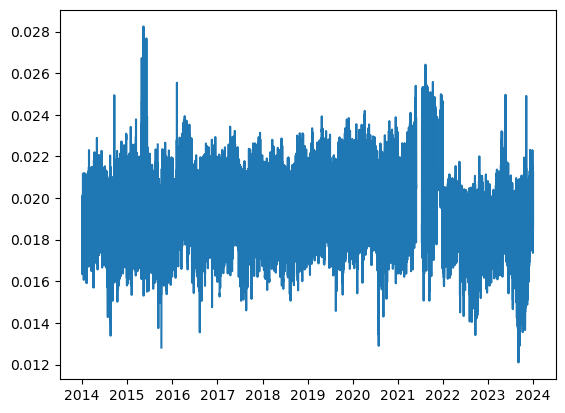

In [40]:
plt.plot(df_atto_raw['q_36m'])

In [42]:
def calculate_vpd(temperature_celsius, relative_humidity_percent):
    """
    Calculates Vapor Pressure Deficit (VPD) from temperature and relative humidity.

    Args:
        temperature_celsius (float): Temperature in degrees Celsius.
        relative_humidity_percent (float): Relative humidity as a percentage (e.g., 75 for 75%).

    Returns:
        float: Vapor Pressure Deficit (VPD) in kilopascals (kPa).
    """

    # 1. Calculate the Saturation Vapor Pressure (Ps) using the Magnus-Tetens formula.
    # The result is in kPa.
    ps_kpa = 0.6108 * np.exp((17.27 * temperature_celsius) / (237.3 + temperature_celsius))

    # 2. Calculate the Actual Vapor Pressure (Pv) from relative humidity.
    pv_kpa = ps_kpa * (relative_humidity_percent / 100)

    # 3. Calculate the Vapor Pressure Deficit (VPD).
    vpd_kpa = ps_kpa - pv_kpa

    return vpd_kpa


In [43]:
df_atto_raw['vpd_36m']=calculate_vpd(df_atto_raw['Tair_36m'],df_atto_raw['RH_36m'])

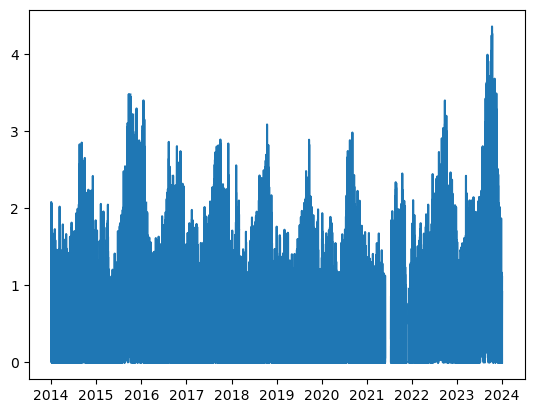

In [44]:
plt.plot(df_atto_raw['vpd_36m'])

In [5]:
df_zf2 = pd.read_csv("../data/BR-Ma2/AMF_BR-Ma2_BASE_HH_1-5.csv", delimiter = ',', skiprows=2)
df_zf2['datetime'] = pd.to_datetime(df_zf2['TIMESTAMP_START'], format='%Y%m%d%H%M')
df_zf2.set_index('datetime', inplace=True)
df_zf2 = df_zf2.replace(-9999.0, np.nan)
df_zf2['Year'] = df_zf2.index.year
df_zf2['Month'] = df_zf2.index.month
df_zf2['Day_of_year'] = df_zf2.index.dayofyear

In [6]:
df_zf2

,TIMESTAMP_START,TIMESTAMP_END,FC,LE,H,SW_IN,TA,RH,USTAR,CO2_1_1_1,...,TA_PI_F,SW_IN_PI_F,P_PI_F,LE_PI_F,H_PI_F,RECO_PI_F,GPP_PI_F,Year,Month,Day_of_year
datetime,,,,,,,,,,,,,,,,,,,,,
1999-01-01 00:00:00,199901010000,199901010030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999,1,1
1999-01-01 00:30:00,199901010030,199901010100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999,1,1
1999-01-01 01:00:00,199901010100,199901010130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999,1,1
1999-01-01 01:30:00,199901010130,199901010200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999,1,1
1999-01-01 02:00:00,199901010200,199901010230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31 21:30:00,201612312130,201612312200,NaN,NaN,NaN,0.0,24.12,96.0,NaN,408.9,...,24.12,0.0,0.0,0.904781,-2.330356,7.251415,NaN,2016,12,366
2016-12-31 22:00:00,201612312200,201612312230,NaN,NaN,NaN,0.0,24.03,96.6,NaN,410.0,...,24.03,0.0,0.0,0.898692,-2.283613,7.224897,NaN,2016,12,366
2016-12-31 22:30:00,201612312230,201612312300,NaN,NaN,NaN,0.0,24.11,95.9,NaN,409.6,...,24.11,0.0,0.0,0.904781,-2.330356,7.248467,NaN,2016,12,366


In [7]:
df_zf2['NEE_PI_F']

datetime
1999-01-01 00:00:00   NaN
1999-01-01 00:30:00   NaN
1999-01-01 01:00:00   NaN
1999-01-01 01:30:00   NaN
1999-01-01 02:00:00   NaN
                       ..
2016-12-31 21:30:00   NaN
2016-12-31 22:00:00   NaN
2016-12-31 22:30:00   NaN
2016-12-31 23:00:00   NaN
2016-12-31 23:30:00   NaN
Name: NEE_PI_F, Length: 315600, dtype: float64

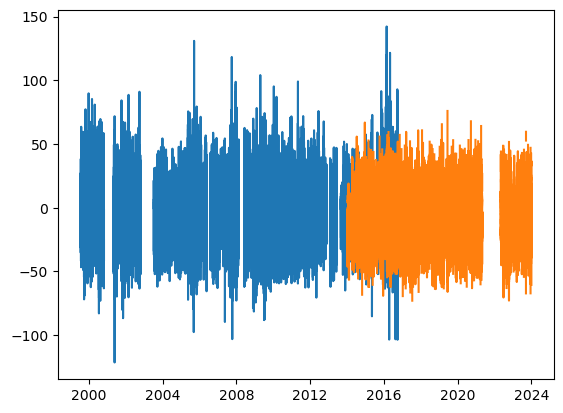

In [10]:
plt.plot(df_zf2['NEE_PI_F']) 
plt.plot(df_atto_raw['NEE_U50_orig'])

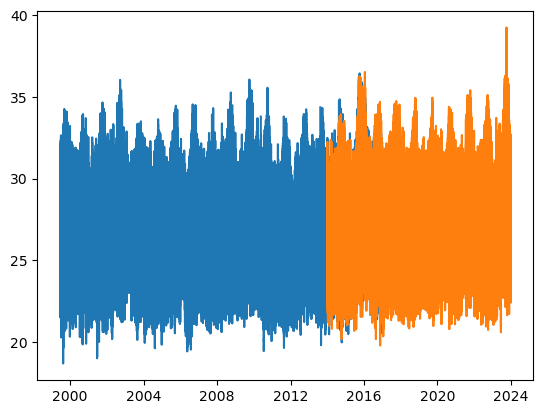

In [11]:
plt.plot(df_zf2['TA']) 
plt.plot(df_atto_raw['Tair_36m'])

In [98]:
df_zf2['Q']=calculate_specific_humidity(df_zf2['TA'],df_zf2['RH'] , df_zf2['PA']*10)

In [85]:
vars_atto = ["Tair_36m", "q_36m", "LW_atm_calc", 'SW_in_GF (W/m2)',  'AP_36m_kPa', 'Rainfall']
vars_zf2 = ["TA", "Q", "LW_IN", 'SW_IN_PI_F',  'PA', 'P']

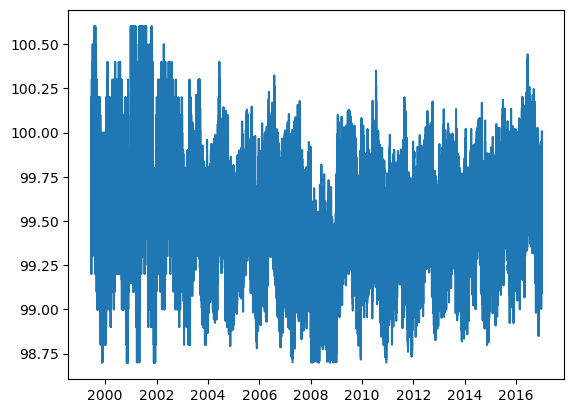

In [94]:
plt.plot(df_zf2['PA'])

df_zf2['P]

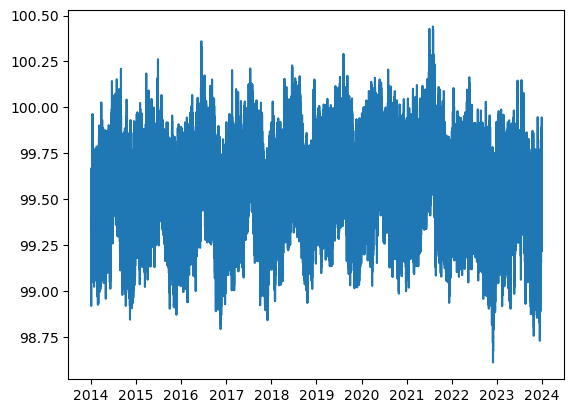

In [97]:
plt.plot(df_atto_raw['AP_36m_kPa'])

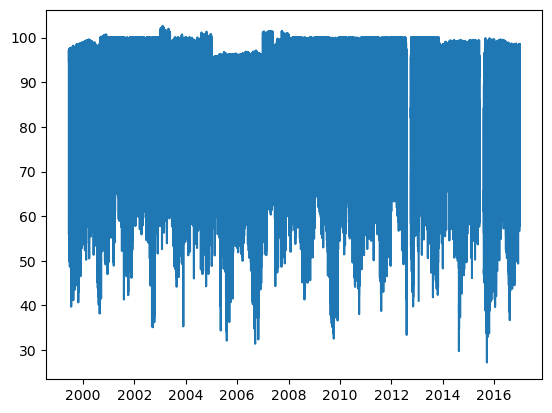

In [83]:
plt.plot(df_zf2['RH'])

/tmp/ipykernel_3288000/3910138389.py:48: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_zf2_grp = df_zf2.groupby(pd.Grouper(freq='30T'))[vnameZf].mean()
/tmp/ipykernel_3288000/3910138389.py:51: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_atto_raw_grp = df_atto_raw.groupby(pd.Grouper(freq='30T'))[vnameAT].mean()
/tmp/ipykernel_3288000/3910138389.py:48: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_zf2_grp = df_zf2.groupby(pd.Grouper(freq='30T'))[vnameZf].mean()
/tmp/ipykernel_3288000/3910138389.py:51: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_atto_raw_grp = df_atto_raw.groupby(pd.Grouper(freq='30T'))[vnameAT].mean()
/tmp/ipykernel_3288000/3910138389.py:48: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' inst

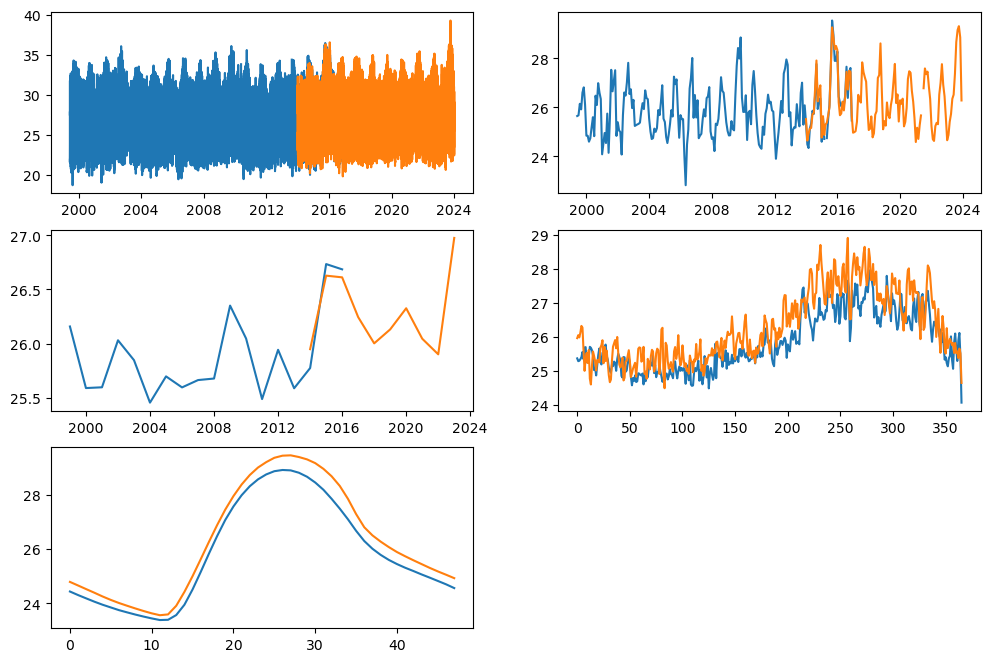

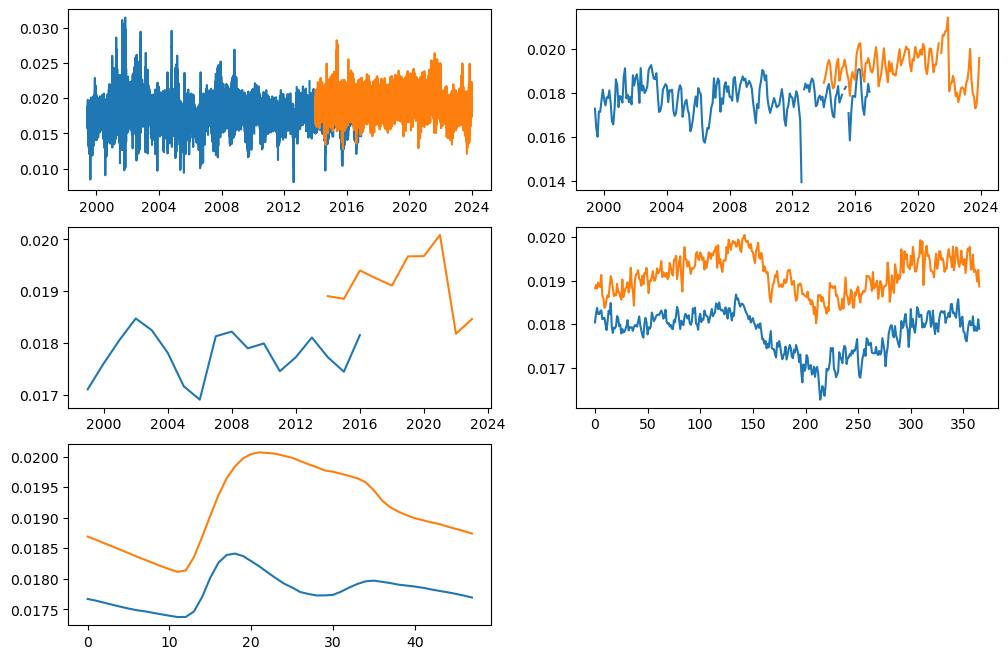

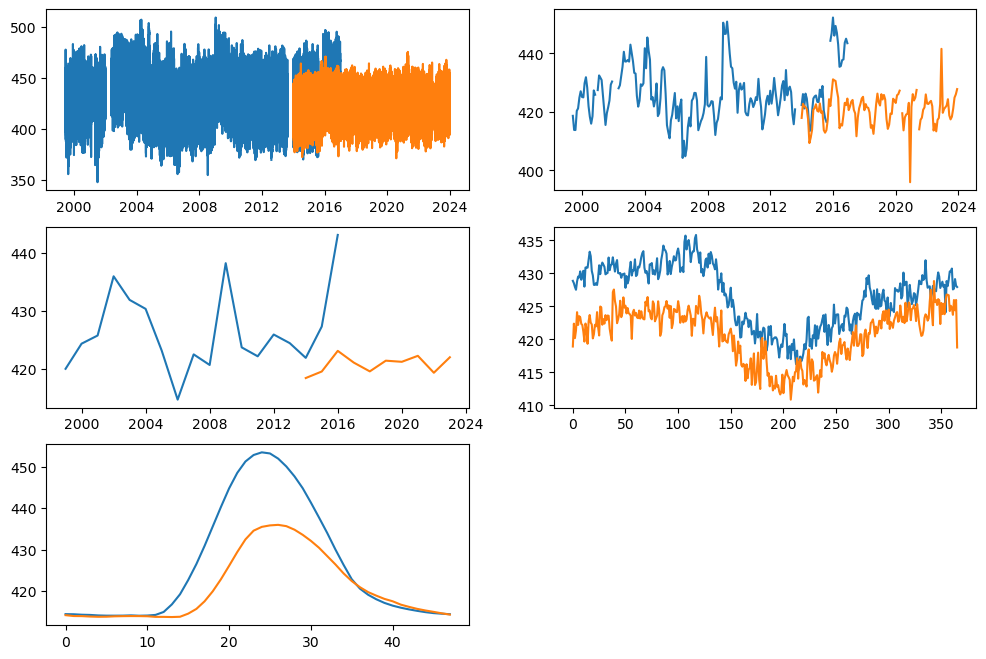

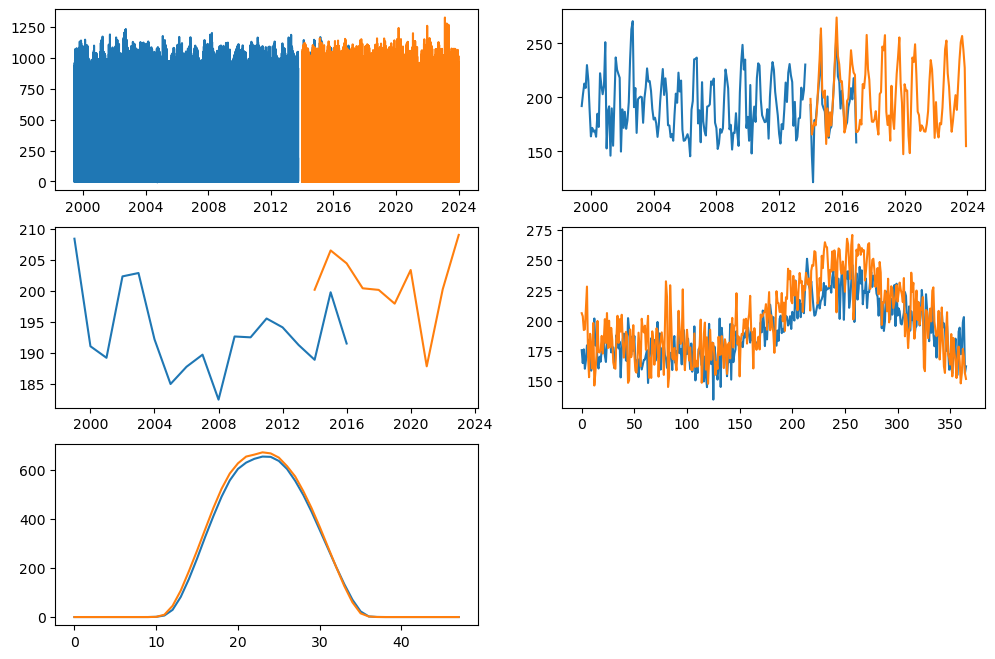

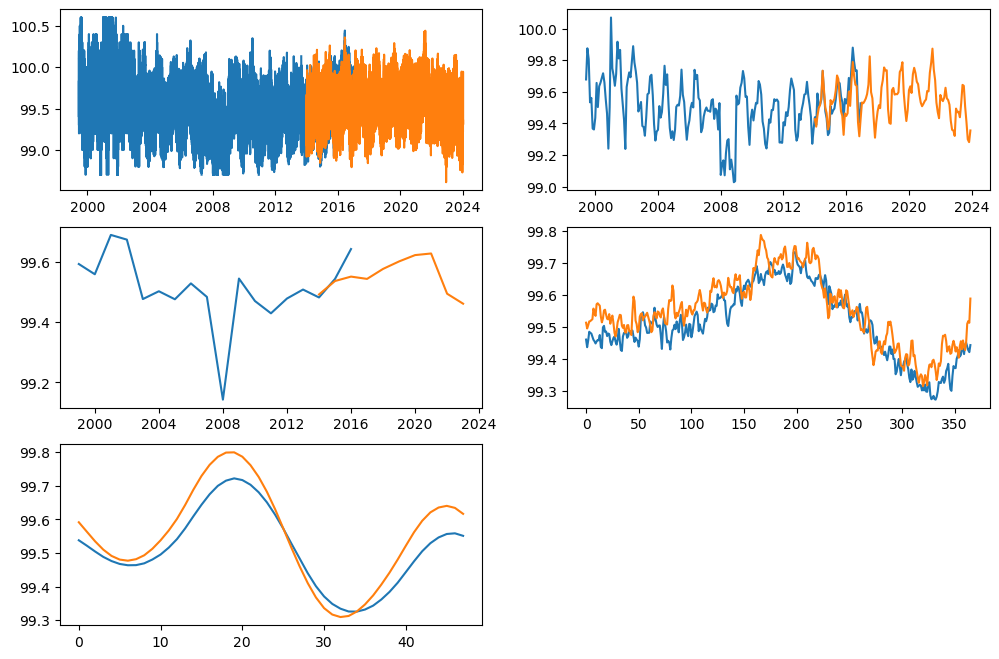

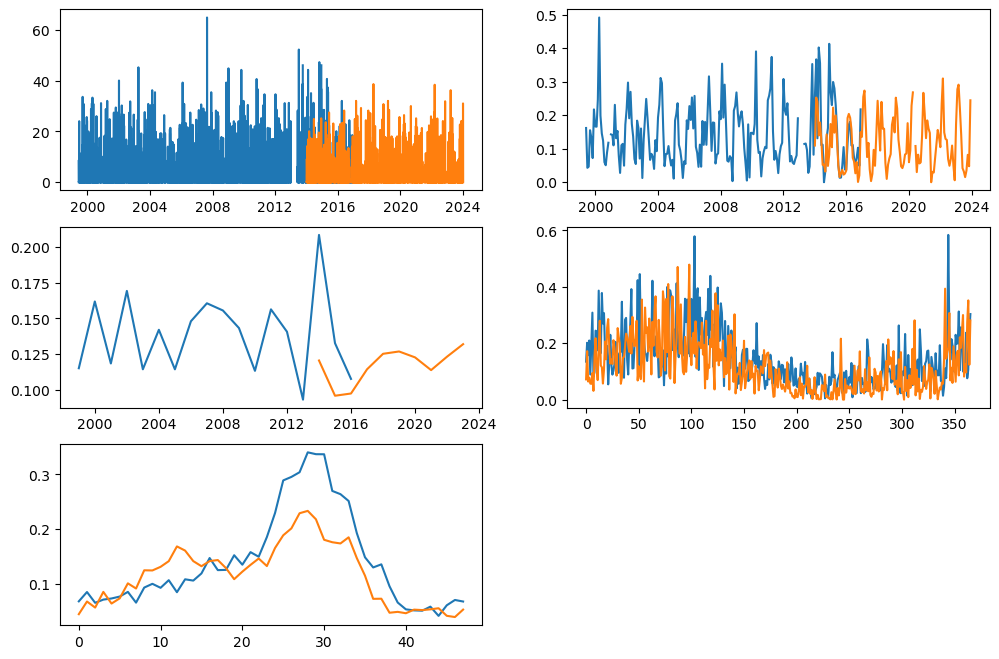

In [99]:
for vnameZf, vnameAT in zip(vars_zf2, vars_atto):
    fig = plt.figure(figsize=(12,8))
    ax  = fig.add_subplot(3,2,1)
    ax.plot(df_zf2[vnameZf])
    ax.plot(df_atto_raw[vnameAT])

    df_zf2_grp = df_zf2.groupby(['Year', 'Month'])[vnameZf].mean().reset_index()
    df_zf2_grp['Period'] = pd.to_datetime(
        df_zf2_grp['Year'].astype(str) + '-' + df_zf2_grp['Month'].astype(str) + '-01'
    )
    df_zf2_grp.set_index(df_zf2_grp['Period'], inplace=True)
    df_atto_raw_grp = df_atto_raw.groupby(['Year', 'Month'])[vnameAT].mean().reset_index()
    df_atto_raw_grp['Period'] = pd.to_datetime(
        df_atto_raw_grp['Year'].astype(str) + '-' + df_atto_raw_grp['Month'].astype(str) + '-01'
    )
    df_atto_raw_grp.set_index(df_atto_raw_grp['Period'], inplace=True)

    ax  = fig.add_subplot(3,2,2)
    ax.plot(df_zf2_grp[vnameZf])
    ax.plot(df_atto_raw_grp[vnameAT])



    df_zf2_grp = df_zf2.groupby(['Year'])[vnameZf].mean().reset_index()
    df_zf2_grp['Period'] = pd.to_datetime(
        df_zf2_grp['Year'].astype(str) + '-01-01'
    )
    df_zf2_grp.set_index(df_zf2_grp['Period'], inplace=True)
    df_atto_raw_grp = df_atto_raw.groupby(['Year'])[vnameAT].mean().reset_index()
    df_atto_raw_grp['Period'] = pd.to_datetime(
        df_atto_raw_grp['Year'].astype(str) +  '-01-01'
    )
    df_atto_raw_grp.set_index(df_atto_raw_grp['Period'], inplace=True)

    ax  = fig.add_subplot(3,2,3)
    ax.plot(df_zf2_grp[vnameZf])
    ax.plot(df_atto_raw_grp[vnameAT])


    df_zf2_grp = df_zf2.groupby(['Day_of_year'])[vnameZf].mean().reset_index()
    df_atto_raw_grp = df_atto_raw.groupby(['Day_of_year'])[vnameAT].mean().reset_index()

    ax  = fig.add_subplot(3,2,4)
    ax.plot(df_zf2_grp[vnameZf])
    ax.plot(df_atto_raw_grp[vnameAT])


    df_zf2_grp = df_zf2.groupby(pd.Grouper(freq='30T'))[vnameZf].mean()
    df_zf2_grp = pd.DataFrame(df_zf2_grp.groupby(df_zf2_grp.index.time).mean())

    df_atto_raw_grp = df_atto_raw.groupby(pd.Grouper(freq='30T'))[vnameAT].mean()
    df_atto_raw_grp = pd.DataFrame(df_atto_raw_grp.groupby(df_atto_raw_grp.index.time).mean())
    ax  = fig.add_subplot(3,2,5)
    ax.plot(df_zf2_grp[vnameZf].values)
    ax.plot(df_atto_raw_grp[vnameAT].values)


    plt.savefig(f"{vnameZf}.png", dpi =300);


In [65]:
df_zf2_grp['TA'].values

array([24.43419118, 24.30307815, 24.18032356, 24.05931367, 23.9475944 ,
       23.8478495 , 23.7489899 , 23.66651021, 23.58665387, 23.51307357,
       23.44539494, 23.38522372, 23.39417522, 23.56824942, 23.94691976,
       24.51078428, 25.15641199, 25.82779462, 26.47240379, 27.06709992,
       27.5632415 , 27.97585143, 28.30641452, 28.55794591, 28.7388383 ,
       28.85805085, 28.90280427, 28.88812364, 28.8016877 , 28.65374155,
       28.44179822, 28.17602102, 27.84315723, 27.48142263, 27.09022343,
       26.66527703, 26.29012886, 26.00611834, 25.78173412, 25.59609129,
       25.44282274, 25.30800917, 25.18819731, 25.0627486 , 24.94421473,
       24.82212096, 24.69911559, 24.56014683])

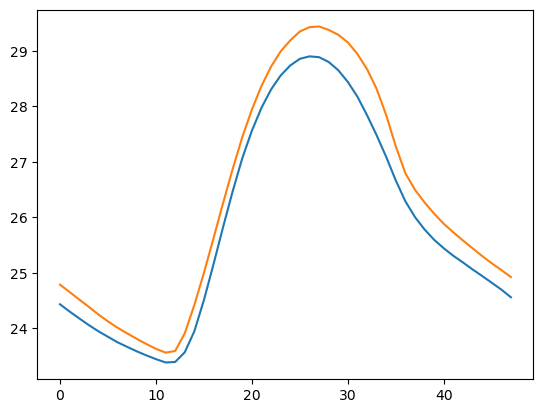